# Task 6: House Price Prediction

### Dataset

In [52]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Housing.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/housing-prices-dataset",
  file_path,
)

df.head()

/tmp/ipykernel_21730/413872352.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'housing-prices-dataset' dataset.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [53]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### Encoding furnishing status with one hot encoder and concatenating

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np

encoder = OneHotEncoder(sparse_output=False, dtype=np.int64, drop='first')
encoded = encoder.fit_transform(df[['furnishingstatus']])

df2 = pd.concat([df.drop('furnishingstatus', axis=1), pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['furnishingstatus']))], axis=1)
df2

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,0,0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,0,0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,1,0
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,0,0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,0,1
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,1,0
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,0,1
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,0,0


In [56]:
for col in ['guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'mainroad']:
    df2[col] = df2[col].apply(lambda x : 1 if x == 'yes' else 0)

In [57]:
df2.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


### Outliers

In [64]:
# q1 = df2['price'].quantile(0.25)
# q3 = df2['price'].quantile(0.75)
# iqr = q3 - q1
# df3 = df2[(df2['price'] < q3 + 1.5 * iqr) & (df2['price'] > q1 - 1.5 * iqr)]

def remove_outliers(df, cols):
    df2 = df.copy()

    for col in cols:
        q1 = df2[col].quantile(0.25)
        q3 = df2[col].quantile(0.75)
        iqr = q3 - q1
        df2 = df2[(df2[col] < q3 + 1.5 * iqr) & (df2[col] > q1 - 1.5 * iqr)]

    return df2

df3 = remove_outliers(df2, ['price', 'area'])
df3

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1,0
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,0,1
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,0,0
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,0,0
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


### Correlation Matrix

<Axes: >

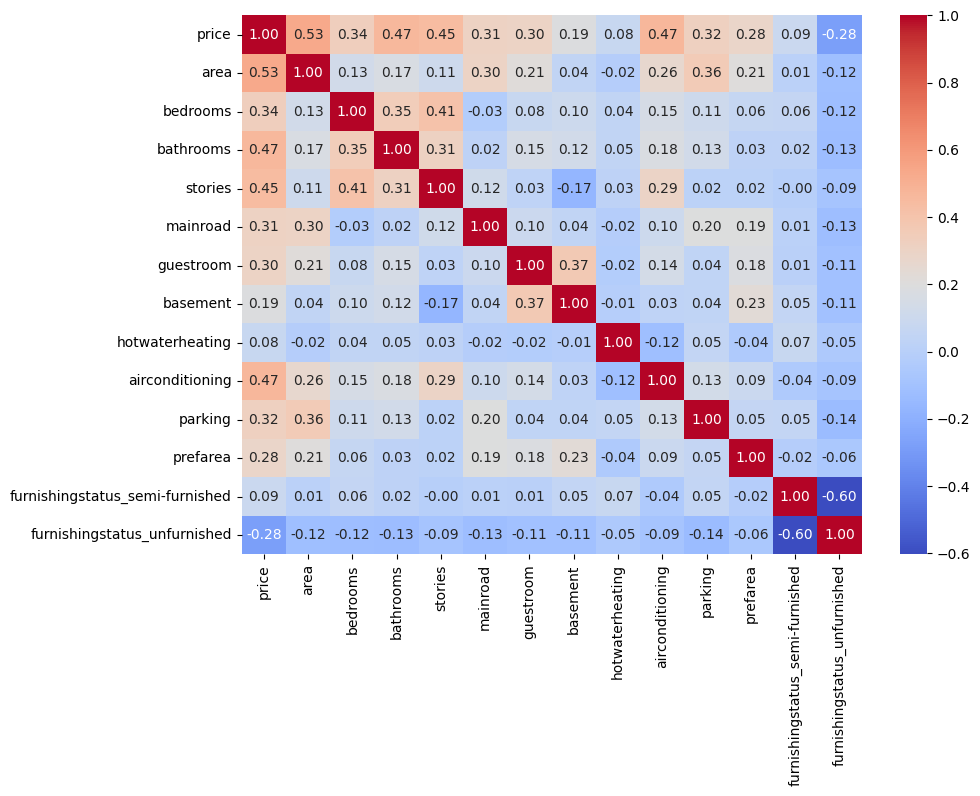

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df3.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

### Splitting

In [90]:
from sklearn.model_selection import train_test_split

X = df3.drop('price', axis=1)
y = df3['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
y_train = np.log1p(y_train) # because prices are huge and this helps in bringing numbers down a lot

### Scaling

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [92]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)
model = model.fit(X_train, y_train)

In [125]:
y_pred = model.predict(X_test)
y_pred = np.expm1(y_pred) # bring back from log

mse = (np.mean((y_pred - y_test) ** 2))
rmse = np.sqrt(mse)
mae = (np.mean(np.abs(y_pred - y_test)))
print(f'RMSE: ${rmse/1000000:.2f}M')
print(f'MAE: ${mae/1000000:.2f}M')
print(f'\nIt is a decent accuracy since prices varied a lot in a big but sparse range of:\n${df['price'].min() / 1000000:.2f}M to ${df['price'].max() / 1000000:.2f}M\nwith a standard deviation of ${df['price'].std() / 1000000:.2f}M')

RMSE: $0.81M
MAE: $0.63M

It is a decent accuracy since prices varied a lot in a big but sparse range of:
$1.75M to $13.30M
with a standard deviation of $1.87M


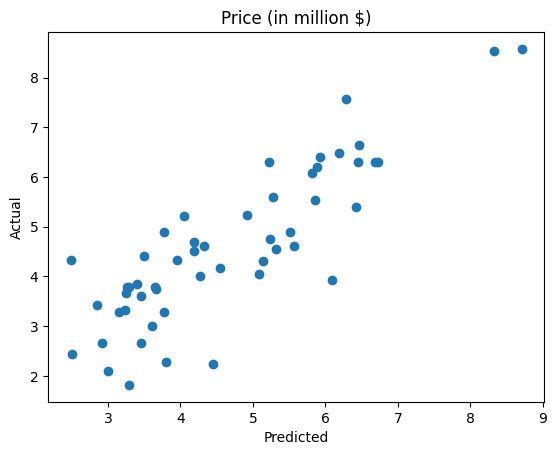

In [123]:
import matplotlib.pyplot as plt

plt.title('Price (in million $)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.scatter(y_pred / 1000000, y_test / 1000000)